# Online Food Delivery Customer Analysis

## Project Overview

This project analyzes customer behavior in an online food delivery dataset.

The analysis focuses on customer demographics, ordering behavior, customer type, family size, education, income, location, occupation, and feedback.

The goal is to identify useful patterns that can support business decisions such as customer targeting, offers, and retention strategies.

## 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [3]:
df = pd.read_csv("/Users/nukavarapuhimasree/Desktop/online food delivery dataset.csv")
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


## 3. Dataset Overview

In [4]:
df.shape

(388, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    str    
 2   Marital Status              388 non-null    str    
 3   Occupation                  388 non-null    str    
 4   Monthly Income              388 non-null    str    
 5   Educational Qualifications  388 non-null    str    
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    str    
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    str    
 12  Feedback                    388 non-null    str    
 13  Unnamed: 13                 388 non-null    st

## 4. Data Cleaning

### 4.1 Check for Duplicate Rows

Duplicate rows can cause the same customer record to be counted more than once, so they should be identified before analysis.

In [6]:
df.duplicated().sum()

np.int64(103)

In [7]:
df[df.duplicated()]

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
43,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
48,23,Female,Single,Student,No Income,Graduate,3,Regular,12.9820,77.6256,560008,Yes,Negative,Yes
49,22,Female,Single,Student,10001 to 25000,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes
52,24,Male,Single,Student,No Income,Post Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
60,23,Male,Single,Student,No Income,Post Graduate,5,Frequent,12.8988,77.5764,560078,Yes,Positive,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,24,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9828,77.6131,560042,Yes,Positive,Yes
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.9766,77.5993,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9854,77.7081,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [ ]:
df = df.drop_duplicates()
df.shape

### 4.2 Check for Missing Values

Missing values can affect calculations and visualizations, so we check every column.

In [8]:
df.isnull().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 13                   0
dtype: int64

### 4.3 Remove the Redundant Column

`Unnamed: 13` contains the same values as `Output`. Since it duplicates information already present in the dataset, it is removed.

In [9]:
(df["Output"] == df["Unnamed: 13"]).all()

np.True_

In [10]:
df = df.drop("Unnamed: 13", axis=1)
df.shape

(388, 13)

## 5. Exploratory Data Analysis

The following questions are used to explore meaningful relationships in the dataset.

## Question 1: Does gender influence online food ordering?

We compare the number of customers who order online across genders.

In [11]:
gender_orders = pd.crosstab(df["Gender"], df["Output"])
gender_orders

Output,No,Yes
Gender,,
Female,40,126
Male,47,175


In [12]:
gender_order_rate = pd.crosstab(
    df["Gender"],
    df["Output"],
    normalize="index"
) * 100

gender_order_rate

Output,No,Yes
Gender,,
Female,24.096386,75.903614
Male,21.171171,78.828829


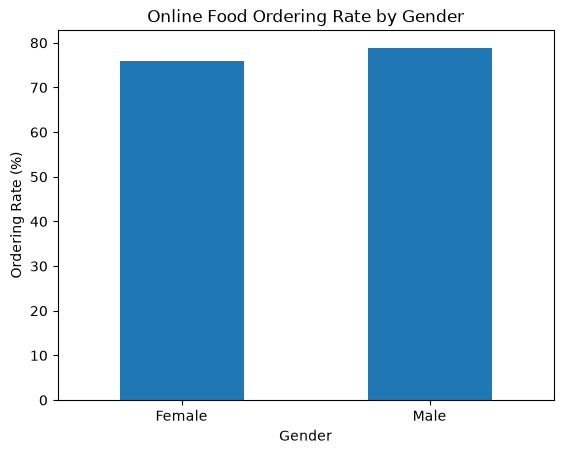

In [13]:
gender_order_rate["Yes"].plot(kind="bar")

plt.title("Online Food Ordering Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Ordering Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Insight

Male customers have a slightly higher online-ordering rate than female customers in this dataset.

This is an observed association in the dataset and does not establish that gender causes ordering behavior.

## Question 2: Which occupations have the most online-ordering customers?

This helps identify occupations that contribute the largest number of online food orders.

In [14]:
occupation_orders = df[df["Output"] == "Yes"]["Occupation"].value_counts()
occupation_orders

Occupation
Student           184
Employee           76
Self Employeed     34
House wife          7
Name: count, dtype: int64

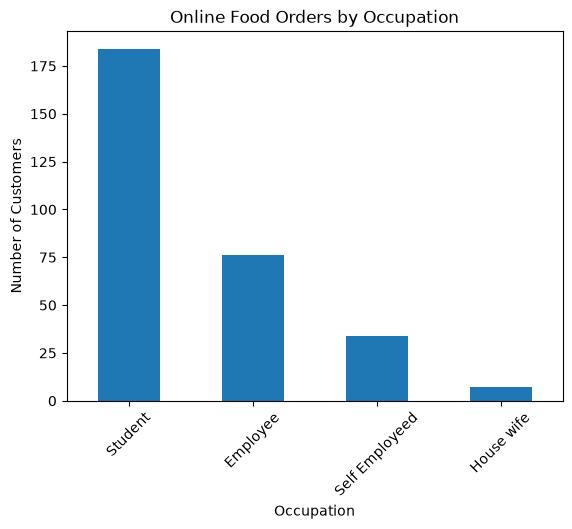

In [15]:
occupation_orders.plot(kind="bar")

plt.title("Online Food Orders by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Insight

The chart shows which occupations contribute the highest number of online-ordering customers in this dataset.

## Question 3: Which pincodes have the highest number of ordering customers?

Pincode is treated as a location identifier rather than a numerical measurement.

In [16]:
pincode_orders = df[df["Output"] == "Yes"]["Pin code"].value_counts()
pincode_orders.head(10)

Pin code
560009    32
560010    13
560038    13
560076    12
560036     9
560034     8
560043     8
560029     8
560095     8
560001     7
Name: count, dtype: int64

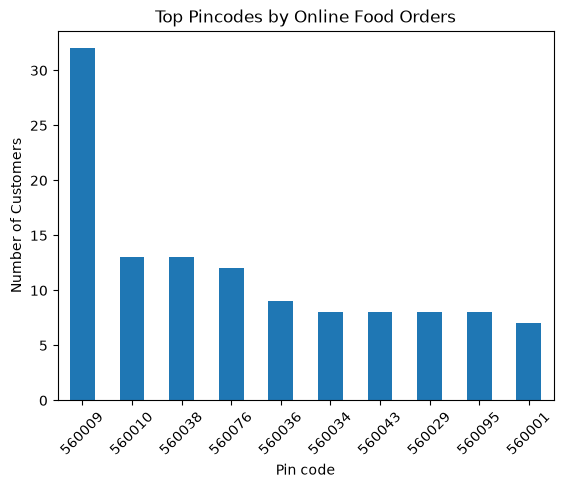

In [17]:
pincode_orders.head(10).plot(kind="bar")

plt.title("Top Pincodes by Online Food Orders")
plt.xlabel("Pin code")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Insight

The top pincodes identify locations with the highest number of online-ordering customers in the dataset.

## Question 4: Which age group orders online food the most?

The dataset contains customers aged 18 to 33. We divide the customers into four age groups to make the pattern easier to understand.

In [18]:
bins = [17, 21, 25, 29, 33]
labels = ["18-21", "22-25", "26-29", "30-33"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_orders = df[df["Output"] == "Yes"]["Age Group"].value_counts().sort_index()
age_orders

Age Group
18-21     30
22-25    203
26-29     44
30-33     24
Name: count, dtype: int64

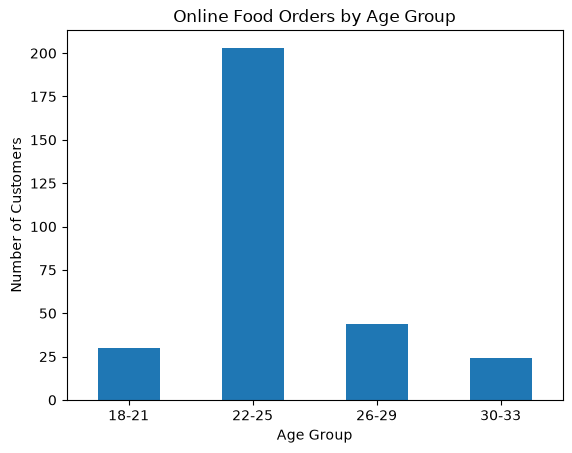

In [19]:
age_orders.plot(kind="bar")

plt.title("Online Food Orders by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Insight

Customers aged 22–25 contribute the largest number of online-ordering customers in this dataset.

This is a count-based observation, not an ordering probability.

## Question 5: How does family size relate to customer type?

We compare family-size groups across New, Regular, and Frequent customers.

In [20]:
family_customer = pd.crosstab(
    df["Customer Type"],
    df["Family size"]
)

family_customer

Family size,1,2,3,4,5,6
Customer Type,,,,,,
Frequent,0,0,0,63,54,29
New,24,0,0,0,0,0
Regular,0,101,117,0,0,0


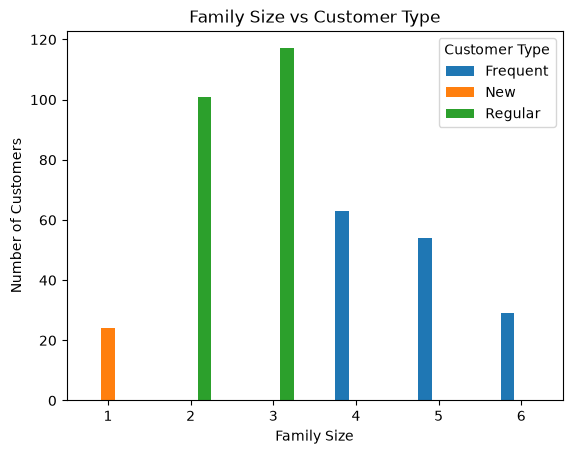

In [21]:
family_customer.T.plot(kind="bar")

plt.title("Family Size vs Customer Type")
plt.xlabel("Family Size")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Insight

In this dataset, New customers are concentrated around smaller family sizes, Regular customers mainly occur in family sizes 2–3, while Frequent customers are more concentrated in larger family sizes.

These are associations in the sample and should not be interpreted as causal relationships.

## Question 6: Does educational qualification relate to online food ordering?

We compare ordering rates across educational qualification groups.

In [22]:
education_orders = pd.crosstab(
    df["Educational Qualifications"],
    df["Output"]
)

education_orders

Output,No,Yes
Educational Qualifications,,
Graduate,50,127
Ph.D,7,16
Post Graduate,27,147
School,2,10
Uneducated,1,1


In [23]:
education_percent = pd.crosstab(
    df["Educational Qualifications"],
    df["Output"],
    normalize="index"
) * 100

education_percent

Output,No,Yes
Educational Qualifications,,
Graduate,28.248588,71.751412
Ph.D,30.434783,69.565217
Post Graduate,15.517241,84.482759
School,16.666667,83.333333
Uneducated,50.000000,50.000000


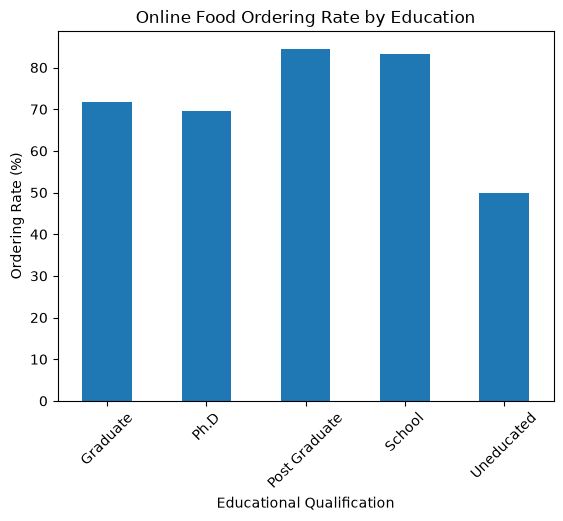

In [24]:
education_percent["Yes"].plot(kind="bar")

plt.title("Online Food Ordering Rate by Education")
plt.xlabel("Educational Qualification")
plt.ylabel("Ordering Rate (%)")
plt.xticks(rotation=45)
plt.show()

### Insight

Post Graduate customers have the highest online-ordering rate among the education groups shown in this dataset.

Some categories have relatively small sample sizes, so their percentages should be interpreted carefully.

### Education Distribution Among Online-Ordering Customers

A pie chart can also show how the online-ordering customer group is distributed across educational qualifications.

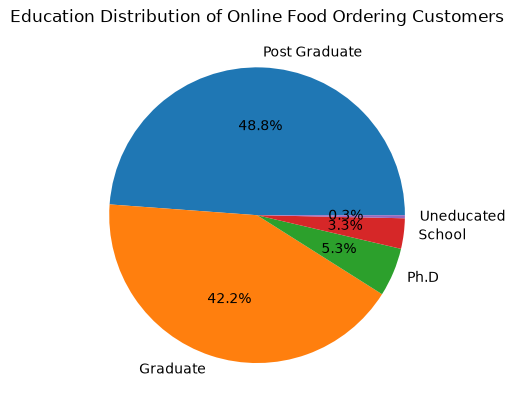

In [25]:
education_orders_yes = df[df["Output"] == "Yes"]["Educational Qualifications"].value_counts()

education_orders_yes.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Education Distribution of Online Food Ordering Customers")
plt.ylabel("")
plt.show()

## Question 7: How does feedback vary by customer type?

We compare positive and negative feedback among New, Regular, and Frequent customers.

In [26]:
feedback_customer = pd.crosstab(
    df["Customer Type"],
    df["Feedback"]
)

feedback_customer

Feedback,Negative,Positive
Customer Type,,
Frequent,26,120
New,6,18
Regular,39,179


In [27]:
feedback_percent = pd.crosstab(
    df["Customer Type"],
    df["Feedback"],
    normalize="index"
) * 100

feedback_percent

Feedback,Negative,Positive
Customer Type,,
Frequent,17.808219,82.191781
New,25.000000,75.000000
Regular,17.889908,82.110092


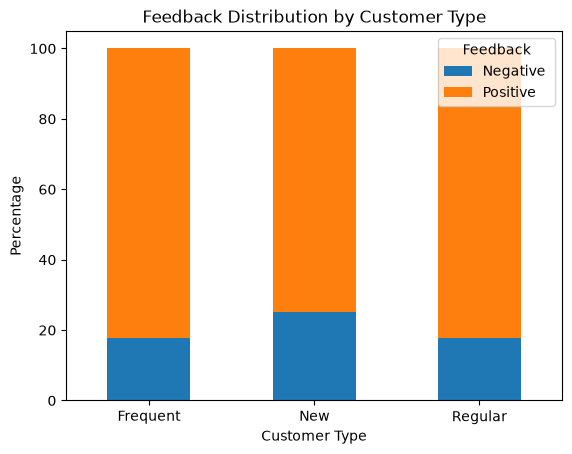

In [28]:
feedback_percent.plot(kind="bar", stacked=True)

plt.title("Feedback Distribution by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Insight

Regular and Frequent customers show slightly higher positive-feedback rates than New customers.

The differences are relatively small, so the dataset does not provide strong evidence of a major feedback difference between customer types.

## Question 8: Does monthly income relate to online food ordering?

Monthly income is treated as a categorical variable because the original dataset stores income as ranges/categories.

In [29]:
income_orders = pd.crosstab(
    df["Monthly Income"],
    df["Output"]
)

income_orders

Output,No,Yes
Monthly Income,,
10001 to 25000,13,32
25001 to 50000,27,42
Below Rs.10000,6,19
More than 50000,18,44
No Income,23,164


In [30]:
income_percent = pd.crosstab(
    df["Monthly Income"],
    df["Output"],
    normalize="index"
) * 100

income_percent

Output,No,Yes
Monthly Income,,
10001 to 25000,28.888889,71.111111
25001 to 50000,39.130435,60.869565
Below Rs.10000,24.000000,76.000000
More than 50000,29.032258,70.967742
No Income,12.299465,87.700535


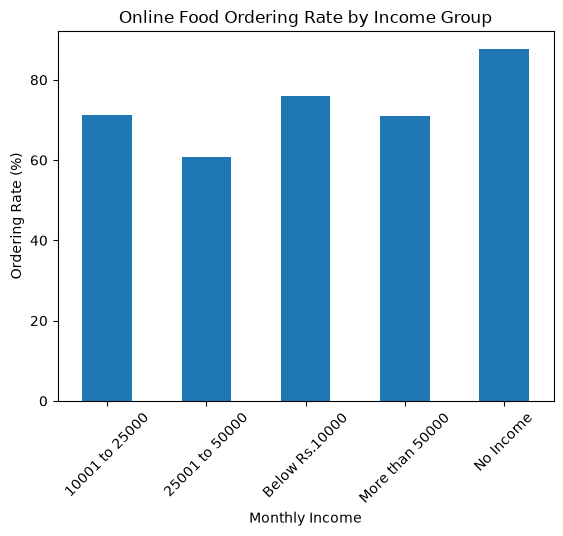

In [31]:
income_percent["Yes"].plot(kind="bar")

plt.title("Online Food Ordering Rate by Income Group")
plt.xlabel("Monthly Income")
plt.ylabel("Ordering Rate (%)")
plt.xticks(rotation=45)
plt.show()

### Insight

The `No Income` group has the highest online-ordering rate in this dataset, while the higher-income groups shown have lower ordering rates.

The `No Income` category may represent students or dependents and should not automatically be interpreted as zero economic activity. The observed pattern is an association, not proof that income causes ordering behavior.

## Question 9: Does gender relate to customer type?

We compare the distribution of New, Regular, and Frequent customers within each gender.

In [32]:
gender_customer = pd.crosstab(
    df["Gender"],
    df["Customer Type"]
)

gender_customer

Customer Type,Frequent,New,Regular
Gender,,,
Female,70,8,88
Male,76,16,130


In [33]:
gender_customer_percent = pd.crosstab(
    df["Gender"],
    df["Customer Type"],
    normalize="index"
) * 100

gender_customer_percent

Customer Type,Frequent,New,Regular
Gender,,,
Female,42.168675,4.819277,53.012048
Male,34.234234,7.207207,58.558559


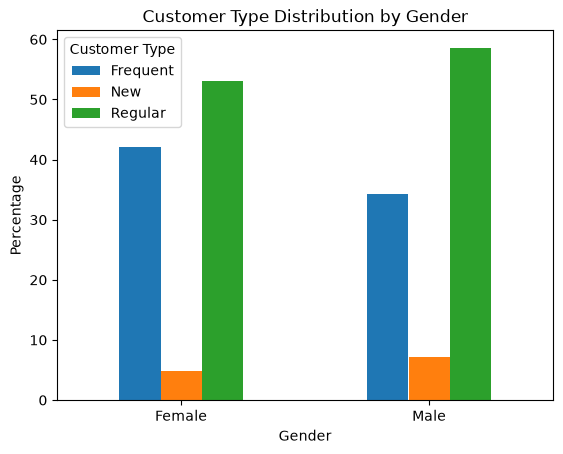

In [34]:
gender_customer_percent.plot(kind="bar")

plt.title("Customer Type Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

### Insight

Regular customers form the largest customer-type group for both genders, and the distributions are fairly similar.

This suggests only a small difference in customer type distribution between male and female customers in this dataset.

# 6. Key Insights

- Male customers have a slightly higher online-ordering rate than female customers.
- Customers aged 22–25 contribute the largest number of online orders.
- Certain occupations and pincodes contribute a larger number of online-ordering customers.
- Customer type shows a visible association with family size.
- Post Graduate customers have the highest ordering rate among the education groups.
- Regular and Frequent customers show slightly higher positive-feedback rates than New customers.
- The `No Income` category has the highest ordering rate in this dataset.
- Customer-type distributions are broadly similar across genders.


# 7. Business Recommendations

Based on the observed patterns:

1. **Target high-ordering age groups** with relevant promotions and meal offers.
2. **Use location-based campaigns** in pincodes with higher ordering activity.
3. **Create family-size offers** tailored to smaller and larger households.
4. **Focus retention efforts on Regular and Frequent customers** because they represent established customer groups.
5. **Monitor feedback by customer type** to identify opportunities to improve the experience of newer customers.
6. **Use occupation and education patterns carefully** for customer segmentation rather than assuming they directly cause ordering behavior.

# 8. Conclusion

This analysis demonstrates how customer demographics and behavioral attributes can be explored using Python and Pandas.

The project includes data cleaning, categorical analysis, percentage-based comparisons, and visualizations to identify meaningful customer patterns.

The findings can help an online food delivery business understand customer segments and design more targeted marketing and retention strategies.

# 9. Technologies Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook